### Import libraries

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import os
import math
import warnings
import numpy as np

import gzip
import re

warnings.filterwarnings('ignore')


### Set file path and directories

In [16]:
root = '/home/ext_sana_noor_astraeabio_com/ext_hd/chiba/'
data_dir = root+'data/'
out = root+'out_july2025/'

xenium_cores = os.listdir( '/home/ext_sana_noor_astraeabio_com/ext_hd/chiba/out_july2025_xenium/script03_gbmap-annotation/script05_gbmap_annotated_xenium_adatas/')

tables_path = '/home/ext_sana_noor_astraeabio_com/ext_hd/chiba/out_july2025_xenium/script06b_tables/'

save_figure_path = '/home/ext_sana_noor_astraeabio_com/ext_hd/chiba/out_july2025_xenium/script06b_figures/'
os.makedirs(save_figure_path, exist_ok=True)


## Set the colour palette for plots and visualizations

In [17]:
colors_palette = [
    '#ebac23', #\n",
    '#b80058', #lipstick 0,140,249 \n",
    '#008cf9', #azure 0,110,0 \n",
    '#006e00', #green 0,187,173 \n",
    '#00bbad', #caribbean 209,99,230 \n",
    '#d163e6', #lavender 178,69,2 \n",
    '#b24502', #brown 255,146,135 \n",
    '#ff9287', #coral 89,84,214 \n",
    '#5954d6', #indigo 0,198,248 \n",
    '#00c6f8', #turquoise 135,133,0 \n",
    '#878500', #olive 0,167,108 \n",
    '#00a76c', #jade 189,189,189 \n",
    '#274d52', #plantation 199,162,166 \n",
    '#c7a2a6', #eunry 129,139,112 \n",
    '#818b70', #battleship 96,78,60 \n",
    '#604e3c', #kabul 140,159,183 \n",
    '#8c9fb7', #balihai 121,104,128 \n",
    '#796880', #rum,\n",
    '#56641a', #fernfrond 192,175,251 \n",
    '#c0affb', #perfume 230,161,118 \n",
    '#e6a176', #apricot 0,103,138 \n",
    '#00678a', #orient 152,68,100 \n",
    '#984464', #vinrouge 94,204,171 \n",
    '#5eccab', #downy\n",
    '#bdbdbd'] #gray\n"

### Load/Read GBMap annotated Anndatas and save in variable adatas

In [18]:
adatas = [sc.read('/home/ext_sana_noor_astraeabio_com/ext_hd/chiba/out_july2025_xenium/script03_gbmap-annotation/script05_gbmap_annotated_xenium_adatas/'+f) for f in xenium_cores if f.endswith('.h5ad')]

In [ ]:
adatas[0].obs['Region'].unique() #

['Edge']
Categories (1, object): ['Edge']

In [20]:
adatas_gb = [adata for adata in adatas if 'GB' in adata.uns['core_id']]
adatas_aa = [adata for adata in adatas if 'AA' in adata.uns['core_id']]
adatas_ol = [adata for adata in adatas if 'Ol' in adata.uns['core_id']]



len(adatas_gb), len(adatas_aa), len(adatas_ol)

(20, 6, 12)

In [21]:
adatas_gb_merged = sc.AnnData.concatenate(*adatas_gb, uns_merge='same')
adatas_aa_merged = sc.AnnData.concatenate(*adatas_aa, uns_merge='same')
adatas_ol_merged = sc.AnnData.concatenate(*adatas_ol, uns_merge='same')

In [22]:
adatas_gb_merged.obs['Samples']

jochkjdi-1-0     GBM10-Edge
jjphpcdd-1-0     GBM10-Edge
jkcelbib-1-0     GBM10-Edge
jkaldpjb-1-0     GBM10-Edge
jkcedffo-1-0     GBM10-Edge
                    ...    
hlhhadnl-1-19     GBM5-Core
hodloebn-1-19     GBM5-Core
hjkdmcde-1-19     GBM5-Core
hlihlamc-1-19     GBM5-Core
agacfgpm-1-19     GBM5-Core
Name: Samples, Length: 91325, dtype: category
Categories (20, object): ['GBM1-Core', 'GBM1-Edge', 'GBM2-Core', 'GBM2-Edge', ..., 'GBM9-Core', 'GBM9-Edge', 'GBM10-Core', 'GBM10-Edge']

### AA merged

In [23]:
sc.pp.normalize_total(adatas_aa_merged, target_sum=500)
sc.pp.log1p(adatas_aa_merged)
sc.pp.pca(adatas_aa_merged)

sc.external.pp.harmony_integrate(adatas_aa_merged, 'Samples')
adatas_aa_merged.obsm['X_pca'] = adatas_aa_merged.obsm['X_pca_harmony']

sc.pp.neighbors(adatas_aa_merged, n_neighbors=50)
sc.tl.umap(adatas_aa_merged, min_dist=0.1, spread=1.0, n_components=2, random_state=369)
sc.tl.leiden(adatas_aa_merged)
sc.tl.rank_genes_groups(adatas_aa_merged, 'annotation_level_3', method='wilcoxon', n_genes=adatas_aa_merged.shape[1], key_added='rank_genes_groups_ctype', use_raw=False)
sc.tl.rank_genes_groups(adatas_aa_merged, 'Region', method='wilcoxon', n_genes=adatas_aa_merged.shape[1], key_added='rank_genes_groups_region', use_raw=False)
sc.tl.filter_rank_genes_groups(adatas_aa_merged, min_in_group_fraction=0.25, min_fold_change=0.5, use_raw=False, key_added='rank_genes_groups_filtered_ctype', key='rank_genes_groups_ctype')
sc.tl.filter_rank_genes_groups(adatas_aa_merged, min_in_group_fraction=0.25, min_fold_change=.5, use_raw=False, key_added='rank_genes_groups_filtered_region', key='rank_genes_groups_region')
#sc.tl.dendrogram(adatas_aa, groupby='leiden', use_raw=False, key_added='dendrogram_int')
#color_map = {str(label): colors_palette[i] for i, label in enumerate(adatas_aa.obs['leiden'].unique())}



2025-07-10 18:51:11,691 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...


2025-07-10 18:51:12,770 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-07-10 18:51:12,806 - harmonypy - INFO - Iteration 1 of 10
2025-07-10 18:51:15,016 - harmonypy - INFO - Iteration 2 of 10
2025-07-10 18:51:17,100 - harmonypy - INFO - Converged after 2 iterations


In [24]:
adatas_aa_merged

AnnData object with n_obs × n_vars = 14304 × 356
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'x_location_px', 'y_location_px', 'y_tma', 'x_tma', 'Samples', 'Region', 'Type', 'Patient', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_5_genes', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_15_genes', 'pct_counts_in_top_20_genes', 'n_counts', 'leiden', 'annotation_level_1', 'annotation_level_1_corr', 'annotation_level_2', 'annotation_level_2_corr', 'annotation_level_3', 'annotation_level_3_corr', 'celltype_original', 'celltype_original_corr', 'cell_type', 'cell_type_corr', 'batch'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts-0', 'mean_counts-0', 'log1p_mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'log1p_total_counts-0', 'n_cells_b

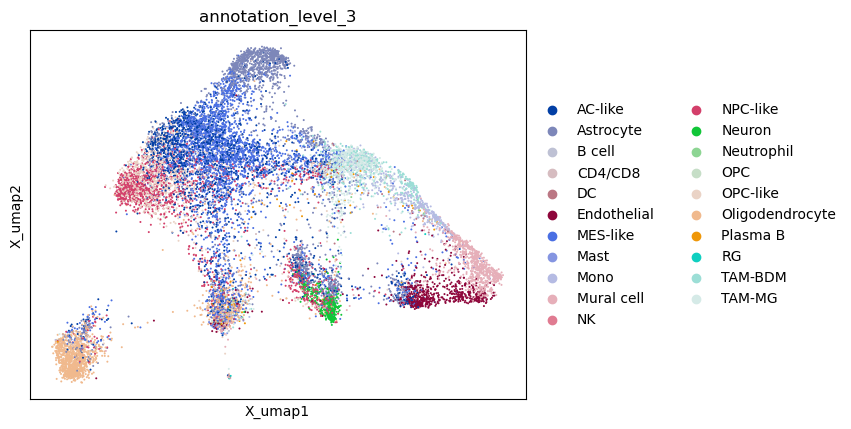

In [25]:
sc.pl.embedding(adatas_aa_merged, basis='X_umap', color='annotation_level_3')

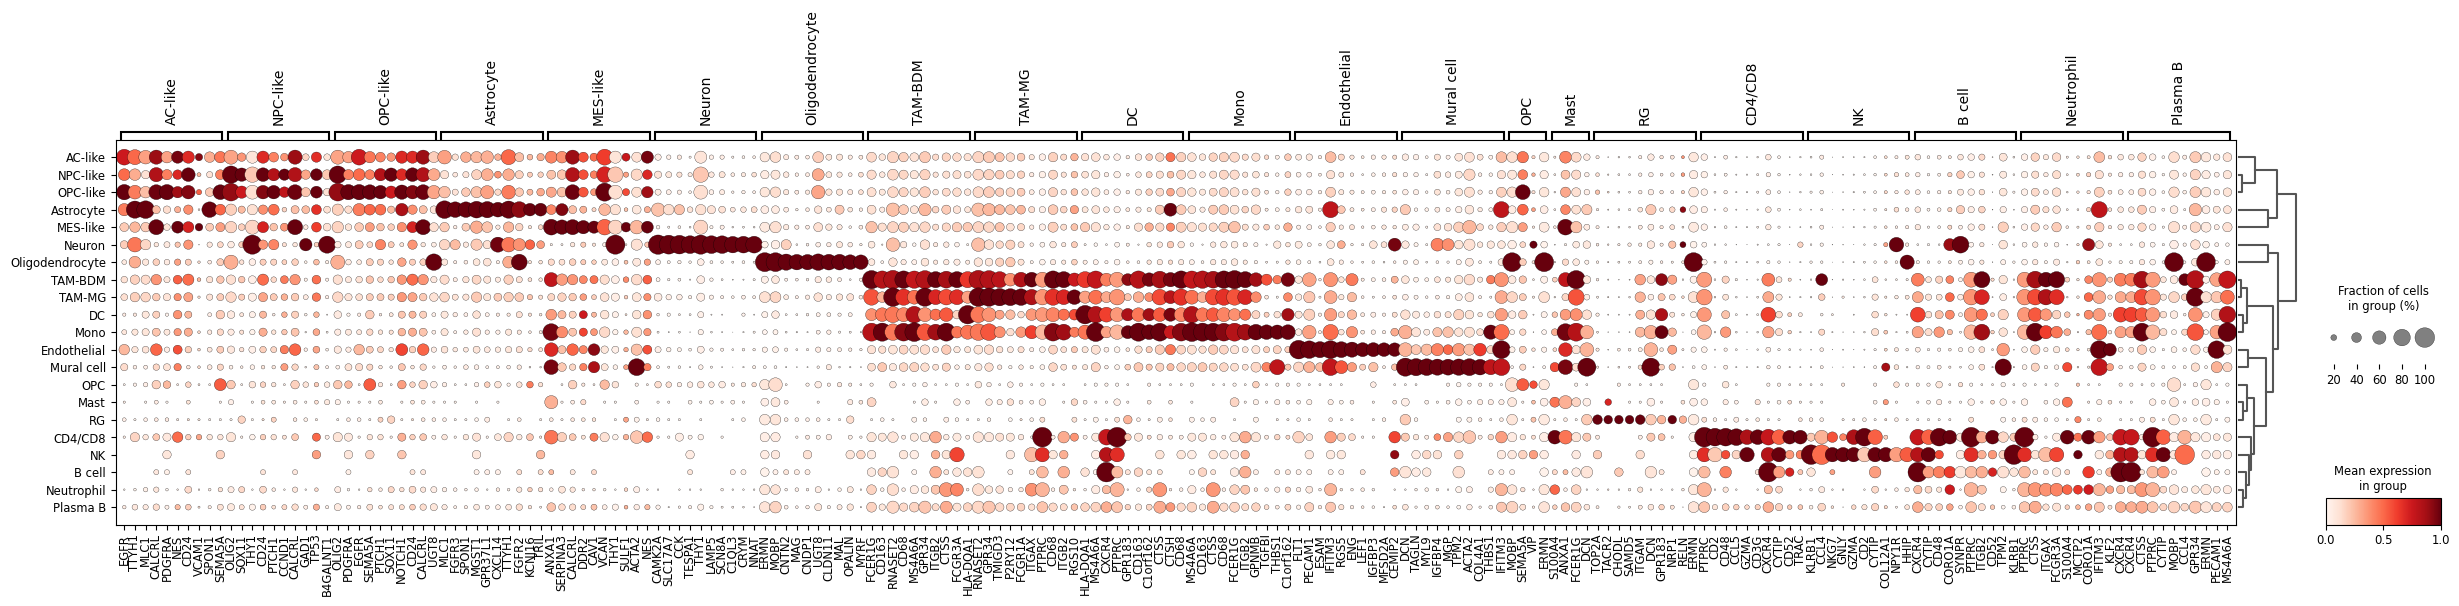

In [26]:
sc.pl.rank_genes_groups_dotplot(adatas_aa_merged, key='rank_genes_groups_filtered_ctype', groupby='annotation_level_3', figsize=(30,5), standard_scale='var')

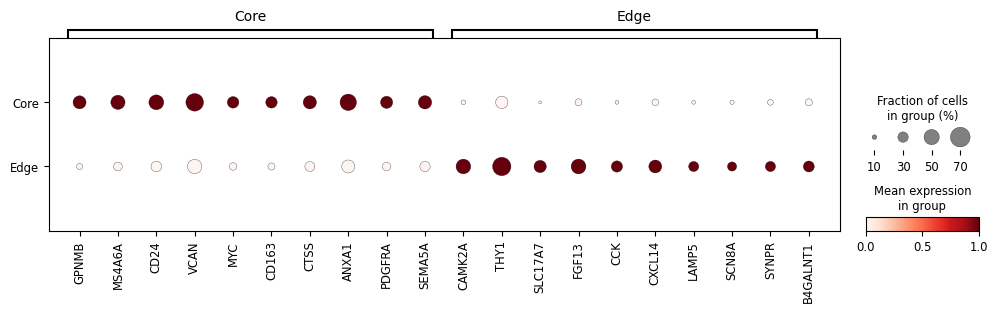

In [27]:
sc.pl.rank_genes_groups_dotplot(adatas_aa_merged, key='rank_genes_groups_filtered_region', groupby='Region', figsize=(12,2.5), standard_scale='var')


### GBM merged

In [28]:
sc.pp.normalize_total(adatas_gb_merged, target_sum=500)
sc.pp.log1p(adatas_gb_merged)
sc.pp.pca(adatas_gb_merged)

sc.external.pp.harmony_integrate(adatas_gb_merged, 'Samples')
adatas_gb_merged.obsm['X_pca'] = adatas_gb_merged.obsm['X_pca_harmony']

sc.pp.neighbors(adatas_gb_merged, n_neighbors=50)
sc.tl.umap(adatas_gb_merged, min_dist=0.1, spread=1.0, n_components=2, random_state=369)
sc.tl.leiden(adatas_gb_merged)
sc.tl.rank_genes_groups(adatas_gb_merged, 'annotation_level_3', method='wilcoxon', n_genes=adatas_gb_merged.shape[1], key_added='rank_genes_groups_ctype', use_raw=False)
sc.tl.rank_genes_groups(adatas_gb_merged, 'Region', method='wilcoxon', n_genes=adatas_gb_merged.shape[1], key_added='rank_genes_groups_region', use_raw=False)
sc.tl.filter_rank_genes_groups(adatas_gb_merged, min_in_group_fraction=0.25, min_fold_change=0.5, use_raw=False, key_added='rank_genes_groups_filtered_ctype', key='rank_genes_groups_ctype')
sc.tl.filter_rank_genes_groups(adatas_gb_merged, min_in_group_fraction=0.25, min_fold_change=.5, use_raw=False, key_added='rank_genes_groups_filtered_region', key='rank_genes_groups_region')
#sc.tl.dendrogram(adatas_aa, groupby='leiden', use_raw=False, key_added='dendrogram_int')
#color_map = {str(label): colors_palette[i] for i, label in enumerate(adatas_aa.obs['leiden'].unique())}



2025-07-10 20:36:20,156 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-07-10 20:36:23,490 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-07-10 20:36:23,841 - harmonypy - INFO - Iteration 1 of 10
2025-07-10 20:36:42,545 - harmonypy - INFO - Iteration 2 of 10
2025-07-10 20:37:01,267 - harmonypy - INFO - Converged after 2 iterations


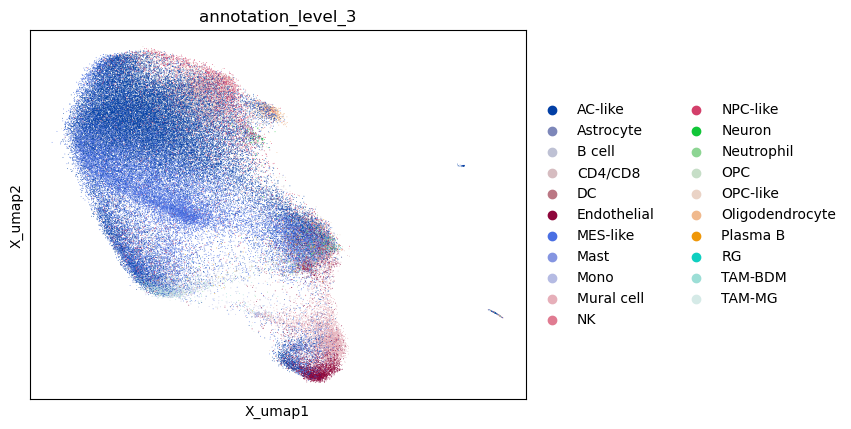

In [29]:
sc.pl.embedding(adatas_gb_merged, basis='X_umap', color='annotation_level_3')  

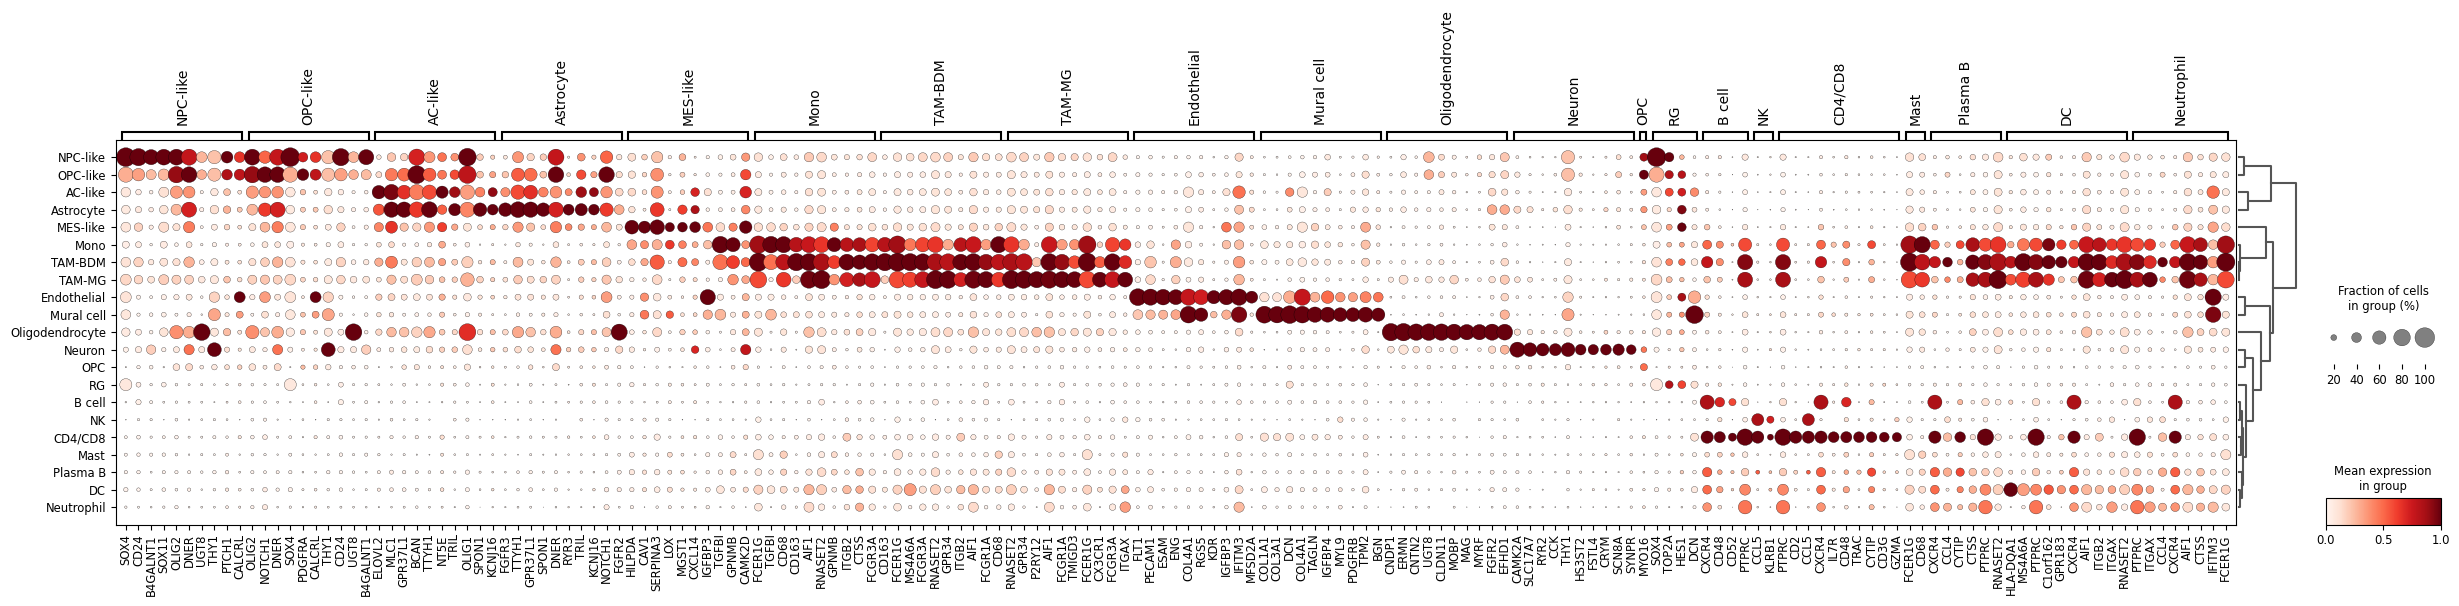

In [30]:
sc.pl.rank_genes_groups_dotplot(adatas_gb_merged, key='rank_genes_groups_filtered_ctype', groupby='annotation_level_3', figsize=(30,5), standard_scale='var')


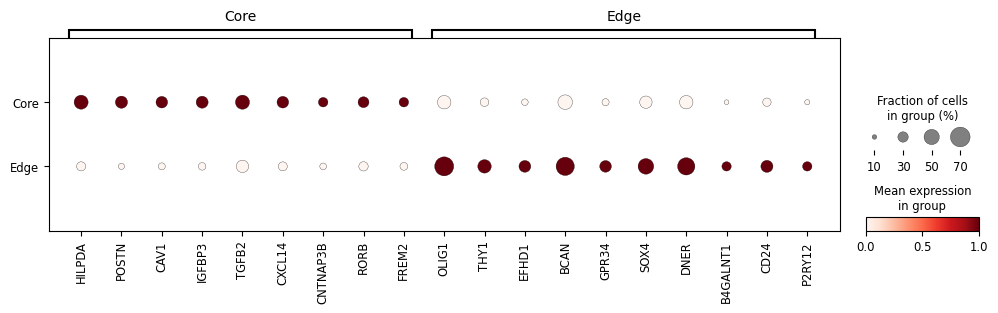

In [32]:
sc.pl.rank_genes_groups_dotplot(adatas_gb_merged, key='rank_genes_groups_filtered_region', groupby='Region', figsize=(12,2.5), standard_scale='var')

### Oligo merged

In [33]:
adatas_ol_merged.obs['Samples']

ldddmjlp-1-0       Oligo2- Edge
kimgbige-1-0       Oligo2- Edge
mdniebgg-1-0       Oligo2- Edge
ldmlcapi-1-0       Oligo2- Edge
kinahnge-1-0       Oligo2- Edge
                      ...      
ljeclkig-1-11    OligoGr3- Core
mhofneea-1-11    OligoGr3- Core
aocbbjgn-1-11    OligoGr3- Core
liedplgm-1-11    OligoGr3- Core
apkfpkph-1-11    OligoGr3- Core
Name: Samples, Length: 49958, dtype: category
Categories (12, object): ['Oligo1- Core', 'Oligo1- Edge', 'Oligo2- Core', 'Oligo2- Edge', ..., 'Oligo5- Core', 'Oligo5- Edge', 'OligoGr3- Core', 'OligoGr3- Edge']

In [34]:
adatas_ol_merged = adatas_ol_merged[~adatas_ol_merged.obs['annotation_level_3'].isin(['B cell', 'NK'])]


sc.pp.normalize_total(adatas_ol_merged, target_sum=500)
sc.pp.log1p(adatas_ol_merged)
sc.pp.pca(adatas_ol_merged)

sc.external.pp.harmony_integrate(adatas_ol_merged, 'Samples')
adatas_ol_merged.obsm['X_pca'] = adatas_ol_merged.obsm['X_pca_harmony']

### drop B cells and NK cells


sc.pp.neighbors(adatas_ol_merged, n_neighbors=50)
sc.tl.umap(adatas_ol_merged, min_dist=0.1, spread=1.0, n_components=2, random_state=369)
sc.tl.leiden(adatas_ol_merged)
sc.tl.rank_genes_groups(adatas_ol_merged, 'annotation_level_3', method='wilcoxon', n_genes=adatas_gb_merged.shape[1], key_added='rank_genes_groups_ctype', use_raw=False)
sc.tl.rank_genes_groups(adatas_ol_merged, 'Region', method='wilcoxon', n_genes=adatas_gb_merged.shape[1], key_added='rank_genes_groups_region', use_raw=False)
sc.tl.filter_rank_genes_groups(adatas_ol_merged, min_in_group_fraction=0.25, min_fold_change=0.5, use_raw=False, key_added='rank_genes_groups_filtered_ctype', key='rank_genes_groups_ctype')
sc.tl.filter_rank_genes_groups(adatas_ol_merged, min_in_group_fraction=0.25, min_fold_change=.5, use_raw=False, key_added='rank_genes_groups_filtered_region', key='rank_genes_groups_region')
#sc.tl.dendrogram(adatas_aa, groupby='leiden', use_raw=False, key_added='dendrogram_int')
#color_map = {str(label): colors_palette[i] for i, label in enumerate(adatas_aa.obs['leiden'].unique())}



2025-07-10 21:00:45,246 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-07-10 21:00:47,354 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-07-10 21:00:47,482 - harmonypy - INFO - Iteration 1 of 10
2025-07-10 21:00:54,905 - harmonypy - INFO - Iteration 2 of 10
2025-07-10 21:01:02,468 - harmonypy - INFO - Converged after 2 iterations


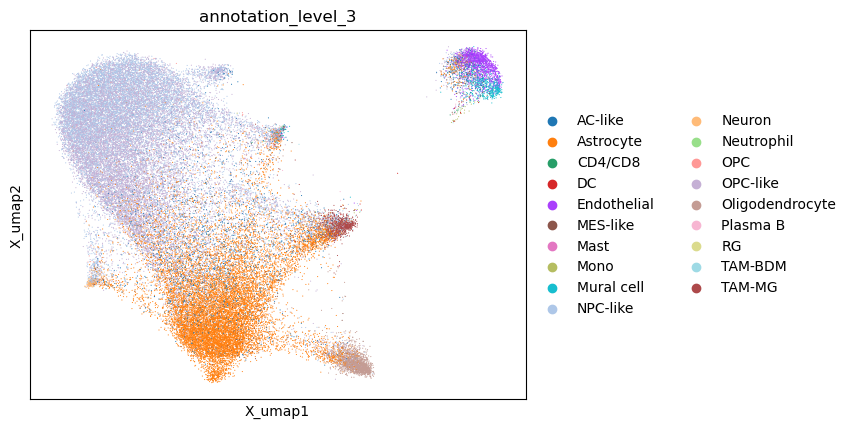

In [35]:
sc.pl.embedding(adatas_ol_merged, basis='X_umap', color='annotation_level_3')  

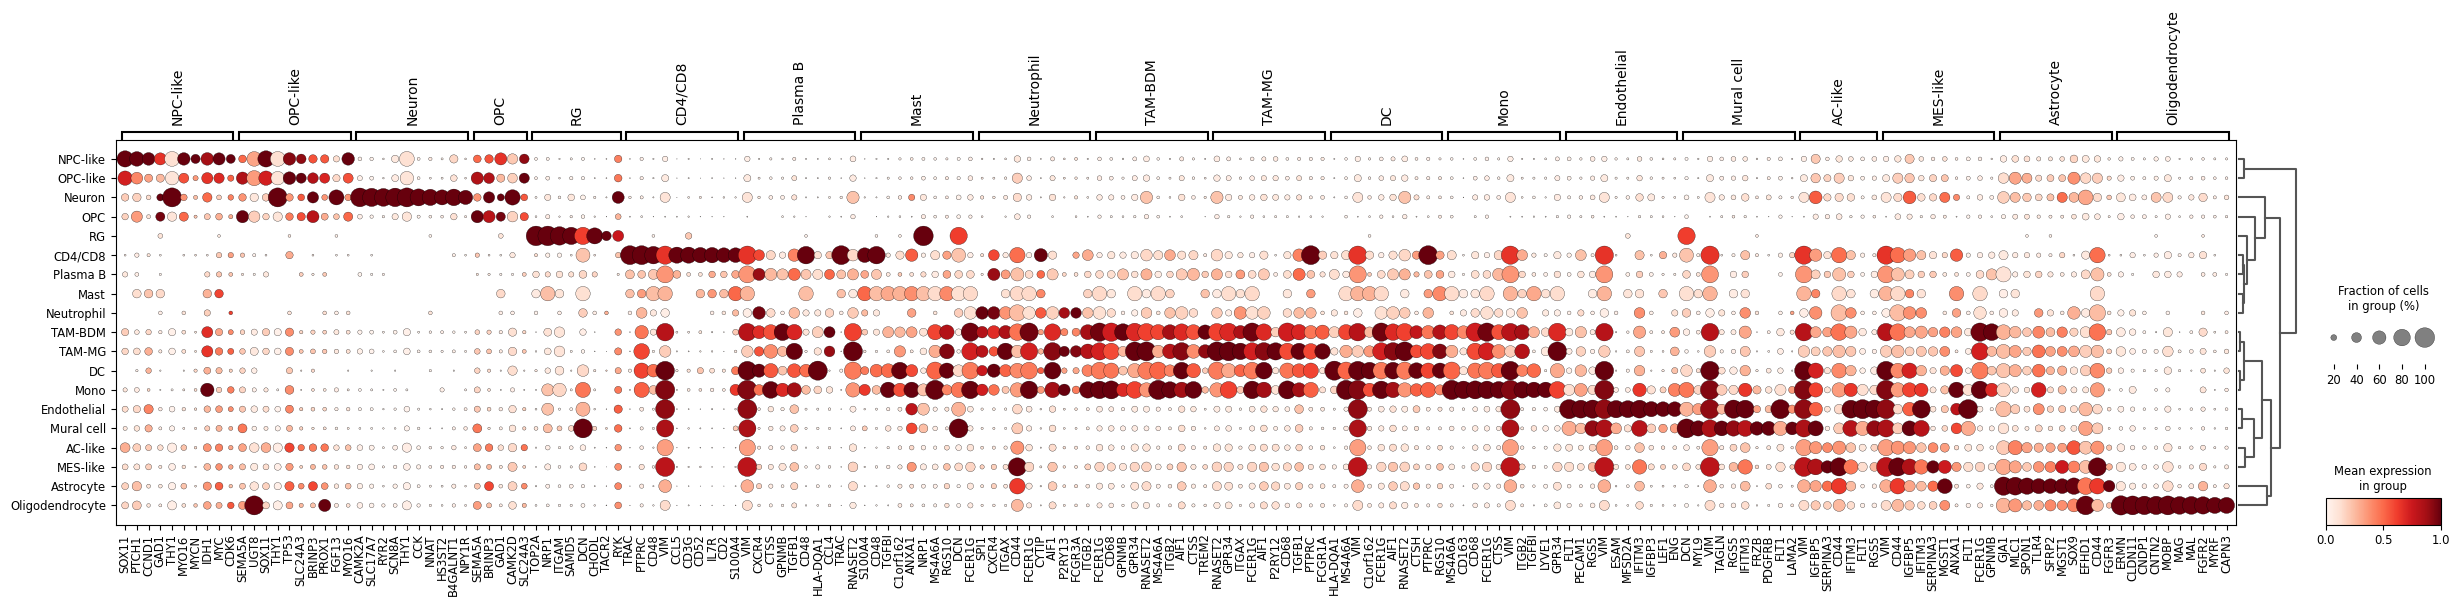

In [36]:
sc.pl.rank_genes_groups_dotplot(adatas_ol_merged, key='rank_genes_groups_filtered_ctype', groupby='annotation_level_3', figsize=(30,5), standard_scale='var')


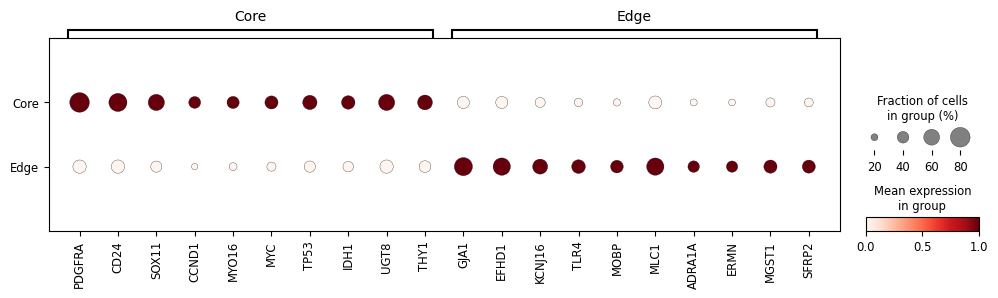

In [38]:
sc.pl.rank_genes_groups_dotplot(adatas_ol_merged, key='rank_genes_groups_filtered_region', groupby='Region', figsize=(12,2.5), standard_scale='var')